In [12]:

# ── Imports ──────────────────────────────────────────

import warnings, os, time
warnings.filterwarnings("ignore")

import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn           as sns
import joblib

from sklearn.neighbors         import KNeighborsClassifier          
from sklearn.naive_bayes       import GaussianNB                    
from sklearn.tree              import DecisionTreeClassifier         
from sklearn.ensemble          import RandomForestClassifier        
from sklearn.svm               import SVC                           
from sklearn.neural_network    import MLPClassifier                 

from sklearn.preprocessing     import LabelEncoder, StandardScaler
from sklearn.model_selection   import StratifiedKFold, cross_val_score
from sklearn.metrics           import (classification_report, confusion_matrix,
                                        ConfusionMatrixDisplay,
                                        f1_score, accuracy_score)
from imblearn.over_sampling    import SMOTE

EMOTIONS = ["angry", "happy", "neutral", "sad", "surprise"]
SEED     = 42
os.makedirs("output/03_train",  exist_ok=True)
os.makedirs("output_model",  exist_ok=True)
np.random.seed(SEED)

In [13]:
# ── Load CSVs ────────────────────────────────────────
TRAIN_CSV = "csv/features_train_F41.csv"
TEST_CSV  = "csv/features_test_F41.csv"

df_train = pd.read_csv(TRAIN_CSV)
df_test  = pd.read_csv(TEST_CSV)

FEATURE_NAMES = [c for c in df_train.columns if c != "label"]
assert len(FEATURE_NAMES) == 41, f"Expected 41 features, got {len(FEATURE_NAMES)}"

X_train_raw = df_train[FEATURE_NAMES].values
y_train_str = df_train["label"].values
X_test_raw  = df_test[FEATURE_NAMES].values
y_test_str  = df_test["label"].values

le = LabelEncoder()
le.fit(EMOTIONS)
y_train = le.transform(y_train_str)
y_test  = le.transform(y_test_str)

print(f"Train : {X_train_raw.shape}   Test : {X_test_raw.shape}")
print(f"Classes: {list(le.classes_)}")
print("\nClass distribution (train):")
for v, c in zip(*np.unique(y_train_str, return_counts=True)):
    print(f"  {'█' * (c//200)} {v:<10}: {c:>5}")

Train : (24176, 41)   Test : (6043, 41)
Classes: [np.str_('angry'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprise')]

Class distribution (train):
  ███████████████████ angry     :  3995
  ████████████████████████████████████ happy     :  7215
  ████████████████████████ neutral   :  4965
  ████████████████████████ sad       :  4830
  ███████████████ surprise  :  3171


In [14]:
# ── Scale + SMOTE ────────────────────────────────────
# Scale first — required for KNN, SVM, MLP; harmless for tree models
scaler        = StandardScaler()
X_train_sc    = scaler.fit_transform(X_train_raw)
X_test_sc     = scaler.transform(X_test_raw)

# SMOTE on scaled data to oversample angry / sad
smote         = SMOTE(random_state=SEED, k_neighbors=5)
X_res, y_res  = smote.fit_resample(X_train_sc, y_train)

print(f"Before SMOTE : {X_train_sc.shape}")
print(f"After  SMOTE : {X_res.shape}")
print("\nResampled class counts:")
for v, c in zip(*np.unique(le.inverse_transform(y_res), return_counts=True)):
    print(f"  {'█' * (c//200)} {v:<10}: {c:>5}")

Before SMOTE : (24176, 41)
After  SMOTE : (36075, 41)

Resampled class counts:
  ████████████████████████████████████ angry     :  7215
  ████████████████████████████████████ happy     :  7215
  ████████████████████████████████████ neutral   :  7215
  ████████████████████████████████████ sad       :  7215
  ████████████████████████████████████ surprise  :  7215


In [26]:
# ── Define 6 Models ──────────────────────────────────
# Configs chosen to be comparable given ~30k SMOTE samples × 41 features

MODELS = {
    "KNN\n": KNeighborsClassifier(
        n_neighbors = 9,
        weights     = "distance",    # closer neighbours vote stronger
        metric      = "euclidean",
        n_jobs      = -1,
    ),
    "Naive Bayes\n": GaussianNB(
        var_smoothing = 1e-9,        # Laplace-style smoothing
    ),
    "Decision Tree\n": DecisionTreeClassifier(
        criterion    = "entropy",    # C4.5-style information gain
        max_depth    = 20,
        class_weight = "balanced",
        random_state = SEED,
    ),
    "Random Forest\n": RandomForestClassifier(
        n_estimators = 250,
        max_depth    = None,
        max_features = "sqrt",
        class_weight = "balanced",
        random_state = SEED,
        n_jobs       = -1,
    ),
    "SVM\n": SVC(
        kernel       = "rbf",
        C            = 10.0,
        gamma        = "scale",
        class_weight = "balanced",
        probability  = True,
        random_state = SEED,
    ),
    "MLP / ANN\n": MLPClassifier(
        hidden_layer_sizes = (256, 128, 64),
        activation         = "relu",
        solver             = "adam",
        max_iter           = 300,
        early_stopping     = True,
        validation_fraction= 0.1,
        random_state       = SEED,
    ),
}
print(f"{len(MODELS)} models defined:")
for name in MODELS:
    print(f"  • {name.replace(chr(10), ' ')}")

6 models defined:
  • KNN 
  • Naive Bayes 
  • Decision Tree 
  • Random Forest 
  • SVM 
  • MLP / ANN 


In [27]:
# ──Train All 6 Models ───────────────────────────────
results = {}   # model_name → {acc, macro_f1, per_class_f1, train_time, y_pred}

for name, model in MODELS.items():
    label = name.replace("\n", " ")
    print(f"Training {label} …", end=" ", flush=True)
    t0 = time.time()
    model.fit(X_res, y_res)
    elapsed = time.time() - t0

    y_pred   = model.predict(X_test_sc)
    acc      = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    rpt      = classification_report(y_test, y_pred,
                                    target_names=EMOTIONS,
                                    output_dict=True)
    per_cls  = {e: rpt[e]["f1-score"] for e in EMOTIONS}

    results[name] = {
        "acc"        : acc,
        "macro_f1"   : macro_f1,
        "per_class"  : per_cls,
        "train_time" : elapsed,
        "y_pred"     : y_pred,
    }
    print(f"acc={acc:.4f}  macro-F1={macro_f1:.4f}  ({elapsed:.1f}s)")

print("\nAll models trained")

Training KNN  … acc=0.5102  macro-F1=0.5088  (0.0s)
Training Naive Bayes  … acc=0.5138  macro-F1=0.4903  (0.0s)
Training Decision Tree  … acc=0.5060  macro-F1=0.4998  (1.8s)
Training Random Forest  … acc=0.6252  macro-F1=0.6144  (2.8s)
Training SVM  … acc=0.5833  macro-F1=0.5723  (181.7s)
Training MLP / ANN  … acc=0.5489  macro-F1=0.5375  (25.5s)

All models trained


In [28]:
# ── Comparison Table ─────────────────────────────────
rows = []
for name, r in results.items():
    row = {
        "Model"      : name.replace("\n", " "),
        "Accuracy"   : round(r["acc"],      4),
        "Macro-F1"   : round(r["macro_f1"], 4),
        "Train (s)"  : round(r["train_time"],1),
    }
    for emo in EMOTIONS:
        row[f"F1-{emo}"] = round(r["per_class"][emo], 4)
    rows.append(row)

df_cmp = pd.DataFrame(rows).set_index("Model")
df_cmp = df_cmp.sort_values("Macro-F1", ascending=False)

print("═" * 80)
print("CS513 Model Comparison — F41 Feature Set")
print("═" * 80)
print(df_cmp.to_string())
print("═" * 80)

best_name = df_cmp["Macro-F1"].idxmax()
print(f"\nBest model: {best_name}  "
    f"(macro-F1={df_cmp.loc[best_name,'Macro-F1']:.4f})")

df_cmp.to_csv("output/03_train/model_comparison_F41.csv")
print("Saved: output/03_train/model_comparison_F41.csv")

════════════════════════════════════════════════════════════════════════════════
CS513 Model Comparison — F41 Feature Set
════════════════════════════════════════════════════════════════════════════════
                Accuracy  Macro-F1  Train (s)  F1-angry  F1-happy  F1-neutral  F1-sad  F1-surprise
Model                                                                                             
Random Forest     0.6252    0.6144        2.8    0.4925    0.7858      0.5556  0.5011       0.7372
SVM               0.5833    0.5723      181.7    0.4515    0.7590      0.4751  0.4560       0.7199
MLP / ANN         0.5489    0.5375       25.5    0.4355    0.7332      0.4083  0.4337       0.6768
KNN               0.5102    0.5088        0.0    0.3909    0.6546      0.4165  0.4392       0.6426
Decision Tree     0.5060    0.4998        1.8    0.3583    0.6896      0.3966  0.3965       0.6582
Naive Bayes       0.5138    0.4903        0.0    0.2891    0.7031      0.4717  0.3443       0.6434
═════

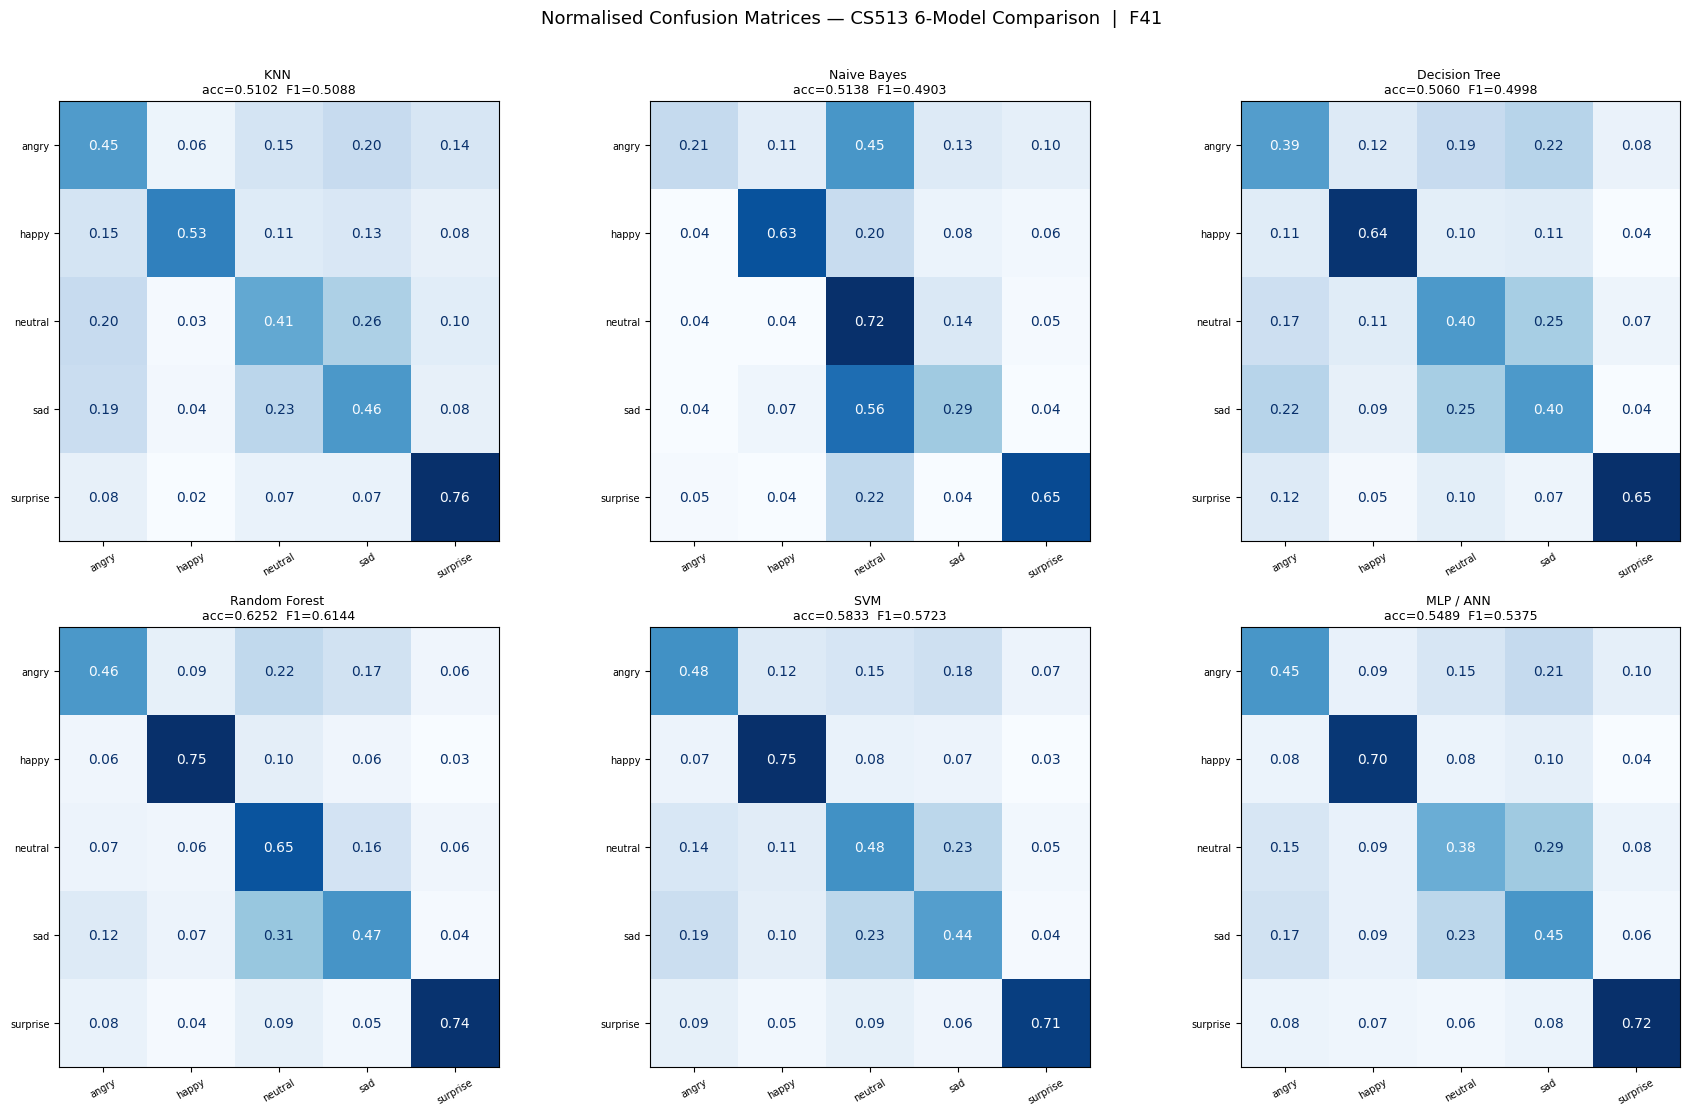

Saved: output/03_train/confusion_all_models_F41.png


In [29]:
# ── Confusion Matrices (2×3 grid) ───────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for ax, (name, r) in zip(axes.flat, results.items()):
    cm   = confusion_matrix(y_test, r["y_pred"],
                            labels=list(range(len(EMOTIONS))))
    norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    ConfusionMatrixDisplay(np.round(norm, 2),
                            display_labels=EMOTIONS).plot(
        ax=ax, colorbar=False, cmap="Blues", values_format=".2f")
    label = name.replace("\n", " ")
    ax.set_title(f"{label}\nacc={r['acc']:.4f}  F1={r['macro_f1']:.4f}",
                fontsize=9)
    ax.tick_params(axis="x", rotation=30, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.suptitle("Normalised Confusion Matrices — CS513 6-Model Comparison  |  F41",
            fontsize=13, y=1.01)
plt.tight_layout()
p = "output/03_train/confusion_all_models_F41.png"
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {p}")

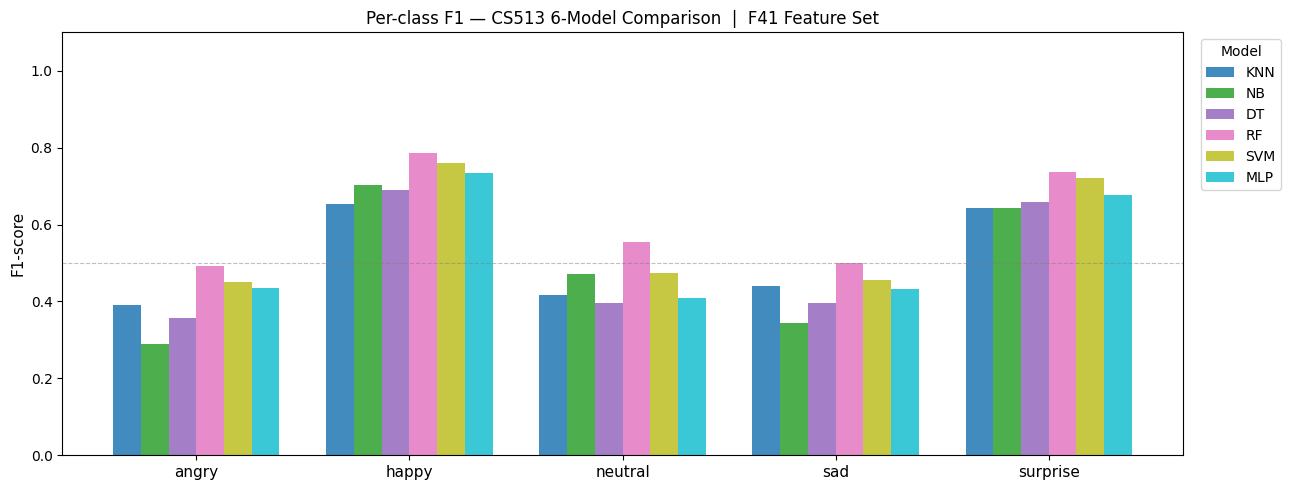

Saved: output/03_train/f1_grouped_bar_F41.png


In [30]:
# ──  Per-class F1 Grouped Bar Chart ───────────────────
model_labels  = [n.replace("\n", "\n") for n in results.keys()]
model_short   = ["KNN", "NB", "DT", "RF", "SVM", "MLP"]
x             = np.arange(len(EMOTIONS))
n_models      = len(results)
width         = 0.13
CMAP          = plt.cm.get_cmap("tab10", n_models)

fig, ax = plt.subplots(figsize=(13, 5))
for i, (name, r) in enumerate(results.items()):
    vals = [r["per_class"][e] for e in EMOTIONS]
    offset = (i - n_models / 2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width,
                label=model_short[i], color=CMAP(i), alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(EMOTIONS, fontsize=11)
ax.set_ylabel("F1-score", fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title("Per-class F1 — CS513 6-Model Comparison  |  F41 Feature Set",
            fontsize=12)
ax.legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.axhline(0.5, color="grey", ls="--", lw=0.8, alpha=0.5)
plt.tight_layout()
p = "output/03_train/f1_grouped_bar_F41.png"
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {p}")

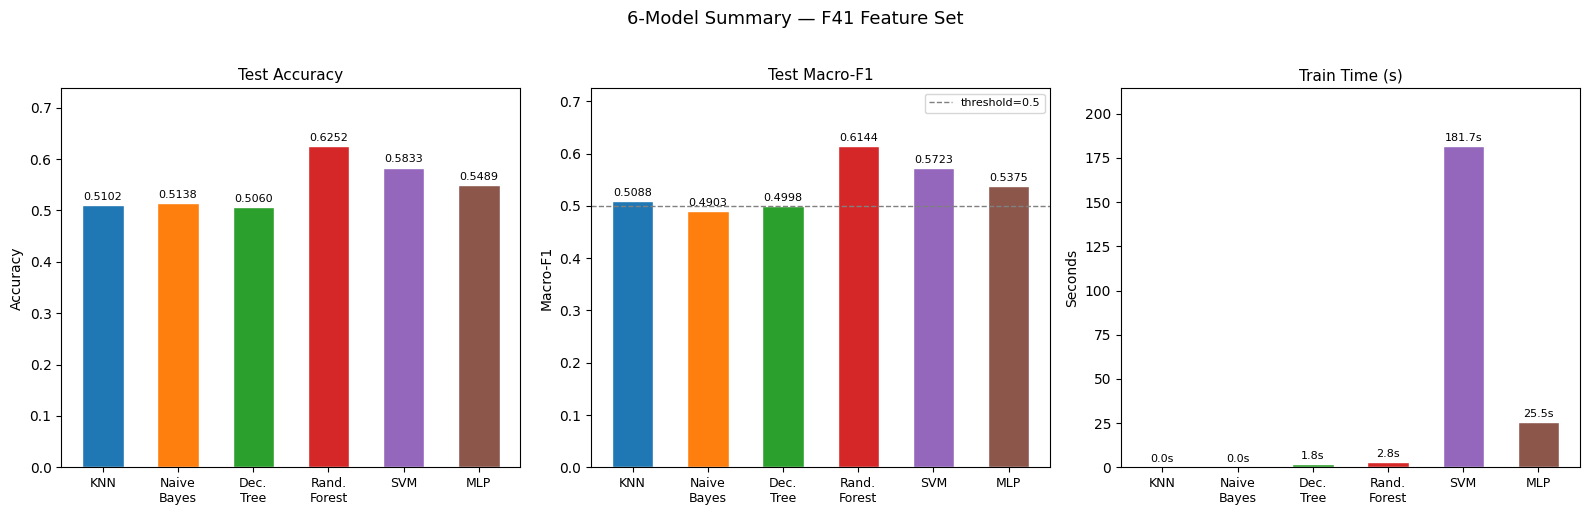

Saved: output/03_train/summary_bar_F41.png


In [31]:
# ── Accuracy + Macro-F1 + Train Time Summary Chart ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

short      = ["KNN", "Naive\nBayes", "Dec.\nTree",
            "Rand.\nForest", "SVM", "MLP"]
accs       = [r["acc"]        for r in results.values()]
f1s        = [r["macro_f1"]   for r in results.values()]
times      = [r["train_time"] for r in results.values()]
COLORS     = [plt.cm.tab10(i) for i in range(len(results))]

def bar_panel(ax, values, title, ylabel, fmt="{:.4f}", threshold=None):
    bars = ax.bar(short, values, color=COLORS, width=0.55, edgecolor="white")
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, v + max(values)*0.01,
                fmt.format(v), ha="center", va="bottom", fontsize=8)
    if threshold:
        ax.axhline(threshold, color="grey", ls="--", lw=1,
                label=f"threshold={threshold}")
        ax.legend(fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_ylim(0, max(values) * 1.18)
    ax.tick_params(axis="x", labelsize=9)

bar_panel(axes[0], accs,  "Test Accuracy",   "Accuracy")
bar_panel(axes[1], f1s,   "Test Macro-F1",   "Macro-F1", threshold=0.5)
bar_panel(axes[2], times, "Train Time (s)",  "Seconds", fmt="{:.1f}s")

plt.suptitle("6-Model Summary — F41 Feature Set", fontsize=13, y=1.02)
plt.tight_layout()
p = "output/03_train/summary_bar_F41.png"
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {p}")

In [34]:
# ── Save Best Model + Artefacts ─────────────────────
best_model_name = df_cmp["Macro-F1"].idxmax()
best_model_key  = [k for k in results if k.replace("\n", " ") == best_model_name][0]
best_model      = MODELS[best_model_key]

joblib.dump(best_model, "output_model/best_model_F41.pkl", compress=3)
joblib.dump(scaler,     "output_model/scaler_F41.pkl")
joblib.dump(le,         "output_model/label_encoder_F41.pkl")

print("Artefacts saved:")
for p in ["output_model/best_model_F41.pkl",
        "output_model/scaler_F41.pkl",
        "output_model/label_encoder_F41.pkl",
        "output/03_train/model_comparison_F41.csv"]:
    kb = os.path.getsize(p) / 1024
    print(f"  {p:<45} ({kb:>7.1f} KB)")

print(f"\n{'═'*60}")
print("Final Comparison")
print(f"{'═'*60}")
for _, row in df_cmp.iterrows():
    flag = "Best:" if row.name == best_model_name else "  "
    print(f"  {flag} {row.name:<30} "
        f"acc={row['Accuracy']:.4f}  F1={row['Macro-F1']:.4f}")
print(f"{'═'*60}")

Artefacts saved:
  output_model/best_model_F41.pkl               (63871.2 KB)
  output_model/scaler_F41.pkl                   (    1.5 KB)
  output_model/label_encoder_F41.pkl            (    0.5 KB)
  output/03_train/model_comparison_F41.csv      (    0.5 KB)

════════════════════════════════════════════════════════════
Final Comparison
════════════════════════════════════════════════════════════
  Best: Random Forest                  acc=0.6252  F1=0.6144
     SVM                            acc=0.5833  F1=0.5723
     MLP / ANN                      acc=0.5489  F1=0.5375
     KNN                            acc=0.5102  F1=0.5088
     Decision Tree                  acc=0.5060  F1=0.4998
     Naive Bayes                    acc=0.5138  F1=0.4903
════════════════════════════════════════════════════════════
